# ПРОЕКТ - ПРЕДСКАЗАНИЯ КАЛОРИЙНОСТИ БЛЮД
**Задача** — создать и обучить нейросеть, которая будет предсказывать калорийность блюд
<br>**Цель** — получить DL-модель, способную оценить калорийность блюда
<br>**Целевая метрика** — MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке

**Датасет**  содержит фотографии блюд, описание ингредиентов, а также общую массу порции и калорийность:
* data/ingredients.csv
<br>* id — ID ингредиента
<br>* ingr — название ингредиента
* data/dish.csv
<br>* dish_id — ID блюда
<br>* total_calories — общее число калорий (**целевая переменная**)
<br>* total_mass — масса блюда
<br>* ingredients — список всех ID ингредиентов в формате ingr_0000000122;ingr_0000000026;.., где ненулевая часть соответствует ID ингредиента из data/ingredients.csv
<br>* split — метка, указывающая, куда отнести блюдо: train/test. Эта метка поможет разделить датасет при тренировке.
* data/images — датасет с фотографиями блюд, каждая директория соответствует dish_id из data/dish.csv и содержит rgb.png фото блюда

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from src.config import Config
from src.utils import train
from src.dataset import DishDataset, collate_fn, get_transforms, build_ingredient_vocab
from src.model import CalorieRegressor

d:\Home\Yandex_Practicum\Deep_Learning\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ (EDA)

In [2]:
df_ingredients = pd.read_csv('data/ingredients.csv')
df_dish = pd.read_csv('data/dish.csv')

In [3]:
df_ingredients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


In [4]:
df_dish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


## ЦЕЛЕВАЯ ПЕРЕМЕННАЯ

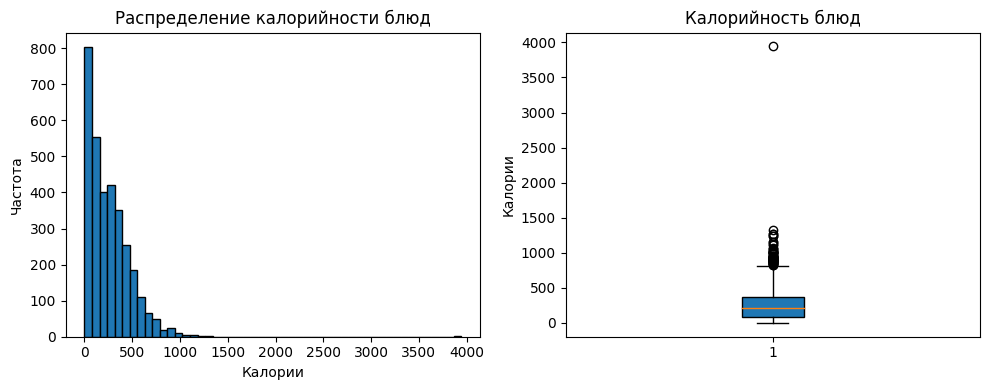

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Гистограмма
ax1.hist(df_dish['total_calories'], bins=50, edgecolor='black')
ax1.set_title("Распределение калорийности блюд")
ax1.set_xlabel("Калории")
ax1.set_ylabel("Частота")

# Boxplot
ax2.boxplot(df_dish['total_calories'], patch_artist=True)
ax2.set_title("Калорийность блюд")
ax2.set_ylabel("Калории")

plt.tight_layout()
plt.show()

In [6]:
df_dish['total_calories'].describe()

count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64

Наблюдается явный выброс в данных. Посмотрим что это за блюдо.

In [7]:
max_calorie_dish = df_dish.loc[df_dish['total_calories'].idxmax()]
dish_id = max_calorie_dish['dish_id']
total_calories = max_calorie_dish['total_calories']
total_mass = max_calorie_dish['total_mass']

ID: dish_1560974769
Калории: 3943.325195
Масса: 3051.0


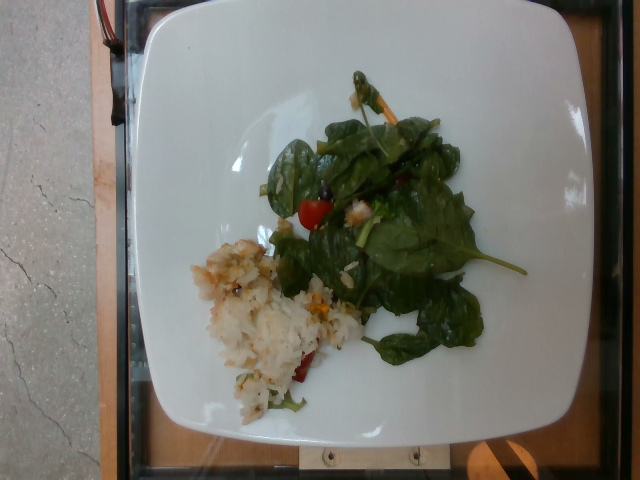

In [8]:
print(f'ID: {dish_id}')
print(f'Калории: {total_calories}')
print(f'Масса: {total_mass}')

image_path = f'data/images/{dish_id}/rgb.png'

img = Image.open(image_path)
display(img)

Картинка не соответствует данным о весе и калорийности блюда. Удалим данное блюдо, чтобы избежать возможных ошибок при обучении модели. 

In [9]:
df_dish = df_dish[df_dish['total_calories'] <= 2000]
df_dish['total_calories'].describe()

count    3261.000000
mean      253.881701
std       209.955428
min         0.000000
25%        80.079994
50%       209.030762
75%       375.109985
max      1324.084961
Name: total_calories, dtype: float64

Блюда с калорийностью равною нулю также вызывают подозрение. Посмотрим пример.

In [10]:
min_calorie_dish = df_dish.loc[df_dish['total_calories'].idxmin()]
dish_id = min_calorie_dish['dish_id']
total_calories = min_calorie_dish['total_calories']
total_mass = min_calorie_dish['total_mass']

ID: dish_1557861216
Калории: 0.0
Масса: 1.0


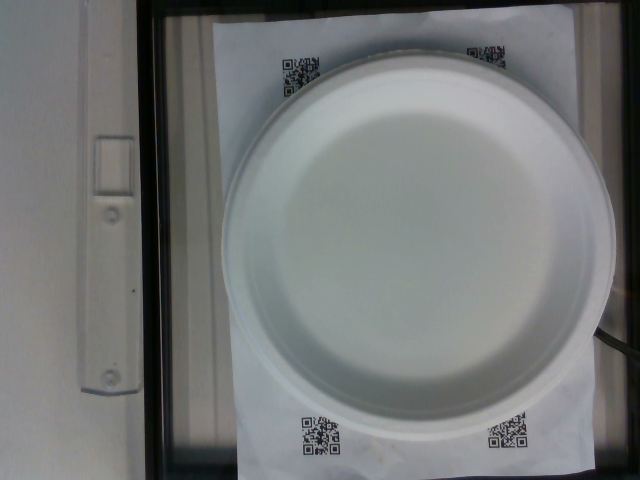

In [11]:
print(f'ID: {dish_id}')
print(f'Калории: {total_calories}')
print(f'Масса: {total_mass}')

image_path = f'data/images/{dish_id}/rgb.png'

img = Image.open(image_path)
display(img)

Мы видим пустую тарелку. Исключим блюда с калорийностью 0 из базы данных

In [12]:
df_dish = df_dish[df_dish['total_calories'] > 0]
df_dish['total_calories'].describe()

count    3259.000000
mean      254.037504
std       209.925582
min         1.150000
25%        80.229595
50%       209.189362
75%       375.118637
max      1324.084961
Name: total_calories, dtype: float64

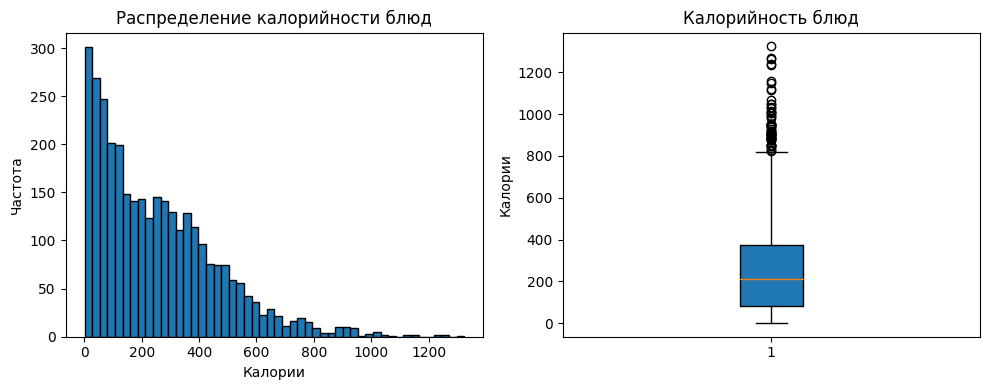

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Гистограмма
ax1.hist(df_dish['total_calories'], bins=50, edgecolor='black')
ax1.set_title("Распределение калорийности блюд")
ax1.set_xlabel("Калории")
ax1.set_ylabel("Частота")

# Boxplot
ax2.boxplot(df_dish['total_calories'], patch_artist=True)
ax2.set_title("Калорийность блюд")
ax2.set_ylabel("Калории")

plt.tight_layout()
plt.show()

## ПРИЗНАК КОЛИЧЕСТВО ИНГРИДИЕНТОВ

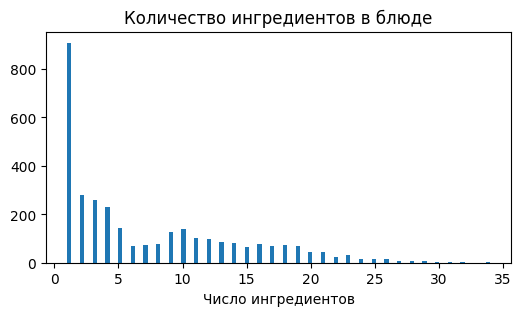

count    3259.000000
mean        7.315127
std         6.943722
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
Name: ingr_count, dtype: float64


In [14]:
# Количество ингредиентов
df_dish.loc[:, 'ingr_count'] = df_dish['ingredients'].str.count(';') + 1
plt.figure(figsize=(6,3))
plt.hist(df_dish['ingr_count'], bins=100)
plt.title("Количество ингредиентов в блюде")
plt.xlabel("Число ингредиентов")
plt.show()

print(df_dish['ingr_count'].describe())

In [15]:
max_ingr_dish = df_dish.loc[df_dish['ingr_count'].idxmax()]
dish_id = max_ingr_dish['dish_id']
total_calories = max_ingr_dish['total_calories']
total_mass = max_ingr_dish['total_mass']

ID: dish_1561578461
Калории: 522.154663
Масса: 392.0


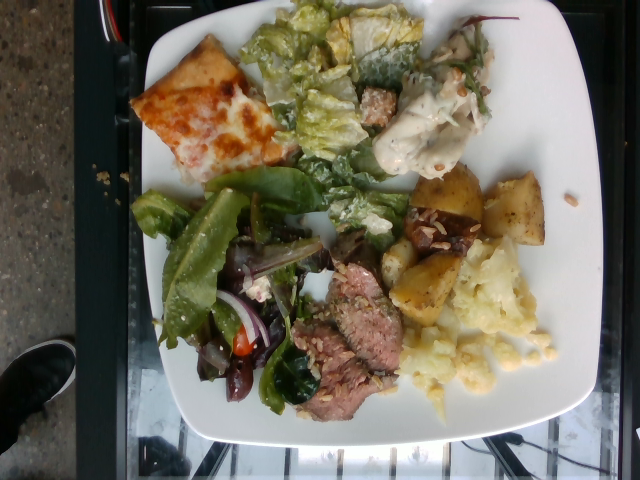

In [16]:
print(f'ID: {dish_id}')
print(f'Калории: {total_calories}')
print(f'Масса: {total_mass}')

image_path = f'data/images/{dish_id}/rgb.png'

img = Image.open(image_path)
display(img)

Изображение соответствует блюду с большим количеством ингридиентов. Не будем ничего удалять

In [17]:
min_ingr_dish = df_dish.loc[df_dish['ingr_count'].idxmin()]
dish_id = min_ingr_dish['dish_id']
total_calories = min_ingr_dish['total_calories']
total_mass = min_ingr_dish['total_mass']

ID: dish_1558372433
Калории: 74.360001
Масса: 143.0


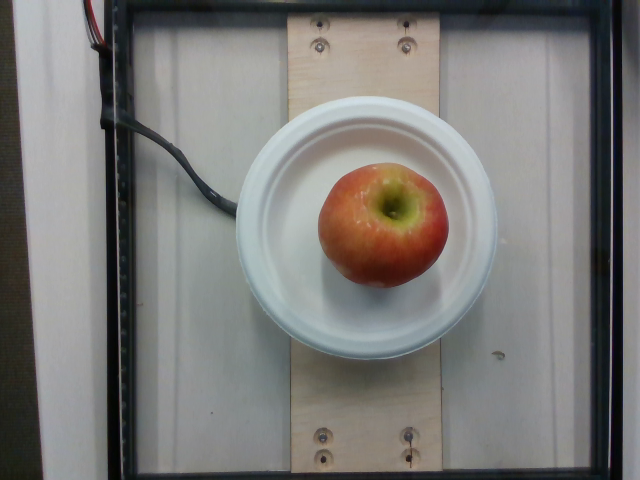

In [18]:
print(f'ID: {dish_id}')
print(f'Калории: {total_calories}')
print(f'Масса: {total_mass}')

image_path = f'data/images/{dish_id}/rgb.png'

img = Image.open(image_path)
display(img)

Блюдо из одного ингридита также соответствует действительности

## СООТНОШЕНИЕ TRAIN и TEST

In [19]:
print("Распределение split:")
print(df_dish['split'].value_counts())

df_train = df_dish[df_dish['split'] == 'train'].reset_index(drop=True)
df_test = df_dish[df_dish['split'] == 'test'].reset_index(drop=True)

# Делим train: 85% остаётся train, 15% уходит в val
df_train_new, df_valid = train_test_split(
    df_train,
    test_size = Config.valid_size,          
    random_state = Config.seed,         
    shuffle=True             
)

# Присваиваем новые метки
df_train_new['split'] = 'train'
df_valid['split'] = 'val'
df_test['split'] = 'test'
df_final = pd.concat([df_train_new, df_valid, df_test], ignore_index=True)

# Сохраняем в файл
file_path = 'data/dish_new.csv'  
df_final.to_csv(file_path, index=False)

# Проверяем результат
print()
print("Обновлённое распределение split:")
print(df_final['split'].value_counts())

Распределение split:
split
train    2753
test      506
Name: count, dtype: int64

Обновлённое распределение split:
split
train    2340
test      506
val       413
Name: count, dtype: int64


## ВЫВОДЫ
Изначально в датасете представлено **3262** блюда
<br>В рамках исследовательского анализа было удалено одно блюдо с нереальным количеством ккал (>2000) и два блюда с калорийностью 0.
<br>В итоговом датасете для обуния будет **3259** блюд
<br>Датасет разделен на обучающую (**2340**), валидационную (**413**) и тестовую (**506**) выборки

Для обучения будет использоваться мультимодальная модель. 
<br>В качестве метрики - MAE - среднее абсолютное отклонение предсказанных значений от фактических значений

# ПАЙПЛАЙН 

Реализованы файлы:
- config.py
- dataset.py
- model.py
- utils.py

Обучение реализуется через запуск одной функции **train**, аргументом для функции служит **класс Config**, прописанный в файле config.py

# ОБУЧЕНИЕ

Epoch 1/30 | train MAE: 200.77 | valid MAE: 98.37


Epoch 2/30 | train MAE: 97.90 | valid MAE: 73.93


Epoch 3/30 | train MAE: 77.00 | valid MAE: 70.03


Epoch 4/30 | train MAE: 74.24 | valid MAE: 61.98


Epoch 5/30 | train MAE: 69.67 | valid MAE: 57.77


...

Epoch 26/30 | train MAE: 44.31 | valid MAE: 49.95


Epoch 27/30 | train MAE: 43.36 | valid MAE: 48.26


Epoch 28/30 | train MAE: 42.02 | valid MAE: 48.97


Epoch 29/30 | train MAE: 42.45 | valid MAE: 44.33


Epoch 30/30 | train MAE: 40.91 | valid MAE: 43.87


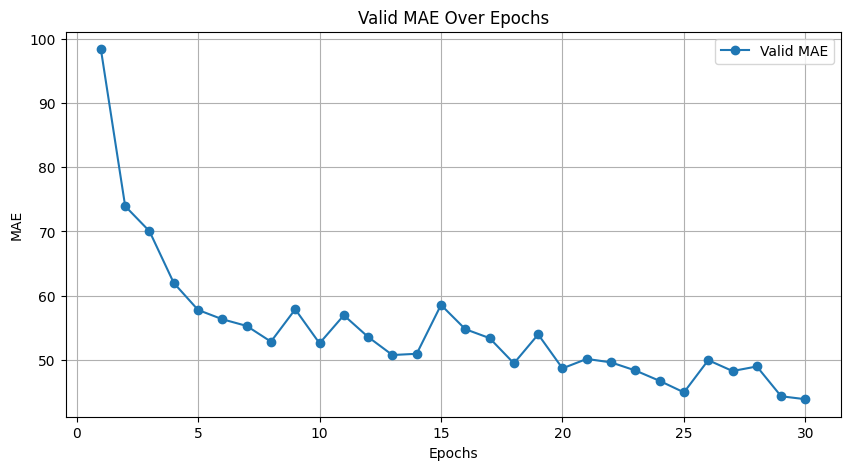

In [20]:
# Запуск обучения
result = train(Config)

# ВАЛИДАЦИЯ КАЧЕСТВА

In [25]:
# load data
dish_df = pd.read_csv(Config.dish_csv)
test_df = dish_df[dish_df["split"] == "test"].reset_index(drop=True)

raw2idx, _ = build_ingredient_vocab(Config.ingredients_csv)
num_ingredients = len(raw2idx)

test_tfms = get_transforms(Config.img_size, is_train=False)
test_ds = DishDataset(test_df, images_dir=Config.images_dir, raw2idx=raw2idx, transform=test_tfms, return_target=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=Config.num_workers, pin_memory=False, collate_fn=collate_fn)

model = CalorieRegressor(
    num_ingredients=num_ingredients,
    ingr_emb_dim=Config.ingr_emb_dim,
    backbone=Config.backbone,
    mlp_hidden=Config.mlp_hidden,
    dropout=Config.dropout,
).to(Config.device)

ckpt = torch.load('model/best_model.pt', map_location=Config.device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

preds_all = []
targets_all = []

with torch.no_grad():
    for batch in test_loader:
        for k in batch:
            batch[k] = batch[k].to(Config.device)
        preds = model(batch)
        preds_all.append(preds.detach().cpu())
        targets_all.append(batch["target"].detach().cpu())

preds_all = torch.cat(preds_all).squeeze(1).numpy()
targets_all = torch.cat(targets_all).squeeze(1).numpy()

mae_test = (abs(preds_all - targets_all)).mean()
print(f'Test MAE: {mae_test:.2f}')

Test MAE: 47.30


**Получена модель с необходимым требованием Test MAE < 50!**

## Результаты исследований

In [26]:
# ТОП-5 примеров с наибольшей ошибкой 
errors = np.abs(preds_all - targets_all)
top_idx = np.argsort(-errors)[:5]

top_rows = test_df.iloc[top_idx].copy()
top_rows["pred"] = preds_all[top_idx]
top_rows["true"] = targets_all[top_idx]
top_rows["abs_error"] = errors[top_idx]

top_rows[["dish_id", "true", "pred", "abs_error", "total_mass"]]

,dish_id,true,pred,abs_error,total_mass
297,dish_1558549806,781.958008,350.884583,431.073425,203.0
169,dish_1566501594,508.048981,184.480576,323.568420,109.0
301,dish_1565030391,609.333923,302.284485,307.049438,313.0
140,dish_1565811139,902.200012,596.411316,305.788696,416.0
93,dish_1563389626,498.620026,198.991333,299.628693,360.0


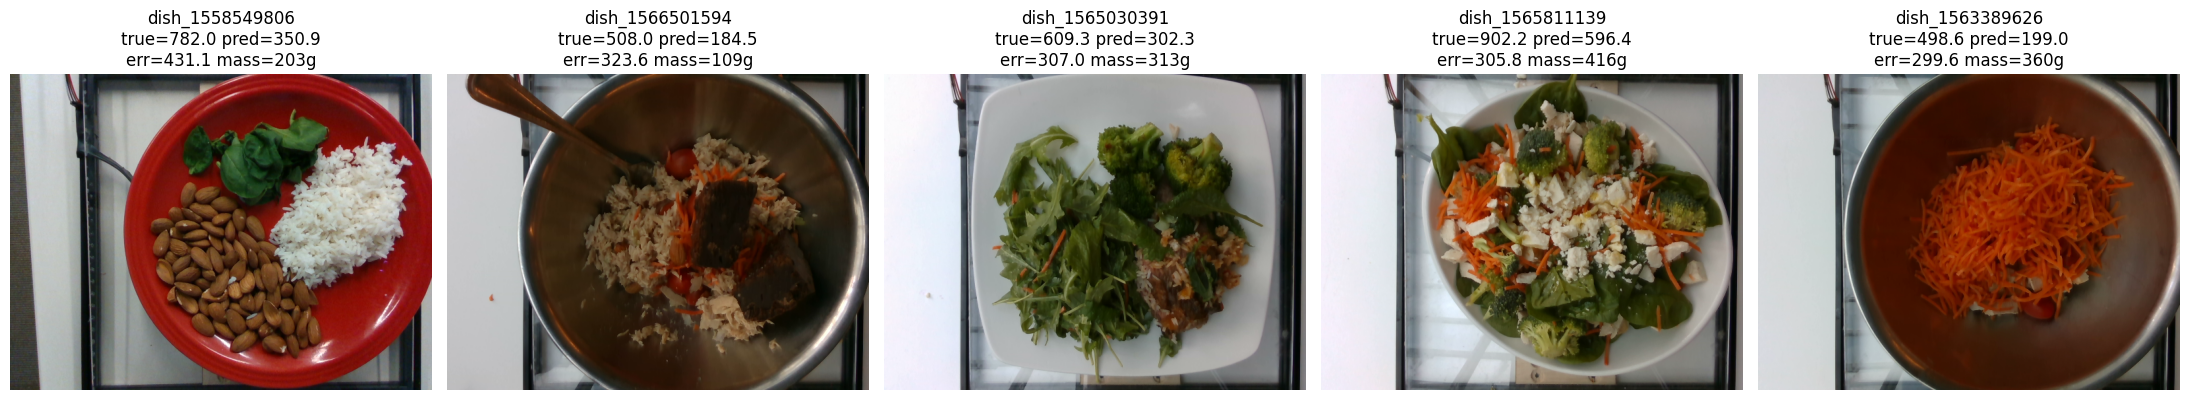

In [27]:
fig, axs = plt.subplots(1, 5, figsize=(22, 5))
for ax, (_, row) in zip(axs, top_rows.iterrows()):
    dish_id = row["dish_id"]
    img_path = Config.images_dir / str(dish_id) / "rgb.png"
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{dish_id}\n"
        f"true={row['true']:.1f} pred={row['pred']:.1f}\n"
        f"err={row['abs_error']:.1f} mass={row['total_mass']:.0f}g"
    )
plt.tight_layout()
plt.show()

Анализ пяти случаев с наибольшей абсолютной ошибкой (MAE) демонстрирует, что модель недооценивает калорийность блюд.

Основные причины низкой точности

* Некоторые ингредиенты могут быть скрыты под другими компонентами или визуально схожи с менее калорийными аналогами. 
* Ингридиенты плохо различимы: масла, жирные соусы, сыр, орехи, сахар и жареные продукты.
* В некоторых случаях масса порции относительно небольшая, что дополнительно влияет на занижение предсказаний модели.